<a href="https://colab.research.google.com/github/kishorykarthikeyan/COVID-19-Death-Rate-Analysis/blob/main/COVID_Death_Rate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [63]:
df.head()

,Unnamed: 0,Country,Date,Confirmed,Death,Recovered,newConfirmed,newDeath,newRecovered
0,1,Afghanistan,2019-12-31,0,0,0,0,0,0
1,2,Afghanistan,2020-01-01,0,0,0,0,0,0
2,3,Afghanistan,2020-01-02,0,0,0,0,0,0
3,4,Afghanistan,2020-01-03,0,0,0,0,0,0
4,5,Afghanistan,2020-01-04,0,0,0,0,0,0


In [65]:
df = pd.read_csv("COVID_Data.csv")
df = pd.read_csv("COVID_Data_Basic.csv")
df.head()

,Unnamed: 0,Country,Date,Confirmed,Death,Recovered,newConfirmed,newDeath,newRecovered
0,1,Afghanistan,2019-12-31,0,0,0,0,0,0
1,2,Afghanistan,2020-01-01,0,0,0,0,0,0
2,3,Afghanistan,2020-01-02,0,0,0,0,0,0
3,4,Afghanistan,2020-01-03,0,0,0,0,0,0
4,5,Afghanistan,2020-01-04,0,0,0,0,0,0


In [67]:
df.columns

Index(['Unnamed: 0', 'Country', 'Date', 'Confirmed', 'Death', 'Recovered',
       'newConfirmed', 'newDeath', 'newRecovered'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Country,0
Date,0
Confirmed,0
Death,0
Recovered,0
newConfirmed,0
newDeath,0
newRecovered,0


In [ ]:
df = df.fillna(0)
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54522 entries, 0 to 54521
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Unnamed: 0    54522 non-null  int64         
 1   Country       54522 non-null  object        
 2   Date          54522 non-null  datetime64[ns]
 3   Confirmed     54522 non-null  int64         
 4   Death         54522 non-null  int64         
 5   Recovered     54522 non-null  int64         
 6   newConfirmed  54522 non-null  int64         
 7   newDeath      54522 non-null  int64         
 8   newRecovered  54522 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 3.7+ MB


In [71]:
total_deaths = df['Death'].sum()
total_recovered = df['Recovered'].sum()
print(total_deaths)
print(total_recovered)

139526813
2499497326


In [ ]:
country_data = df.groupby('Country')[['Confirmed','Death']].sum()

In [ ]:
country_data.sort_values('Death', ascending=False).head(20)

,Confirmed,Death
Country,,
US,915477853,31097010
Brazil,529265598,17348041
India,560488310,9537349
Mexico,84741868,9018679
United Kingdom,77993283,8137034
Italy,62361992,7388994
France,81415778,6320806
Spain,95123771,6214443
Peru,91429593,3657166


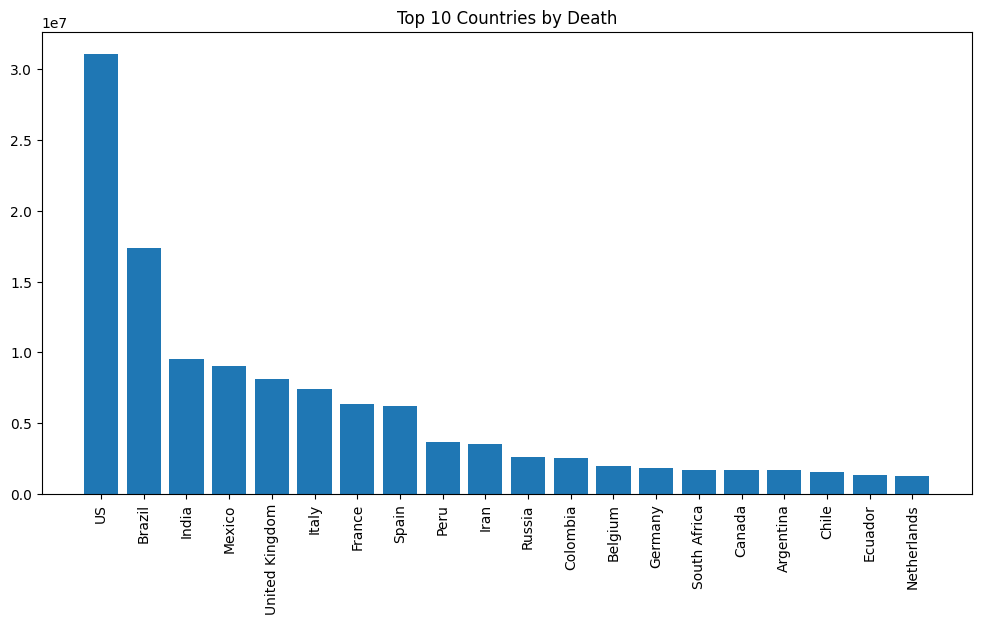

In [72]:
import matplotlib.pyplot as plt
top10 = country_data.sort_values('Death', ascending=False).head(20)

plt.figure(figsize=(12,6))
plt.bar(top10.index, top10['Death'])
plt.xticks(rotation=90)
plt.title('Top 10 Countries by Death')
plt.show()

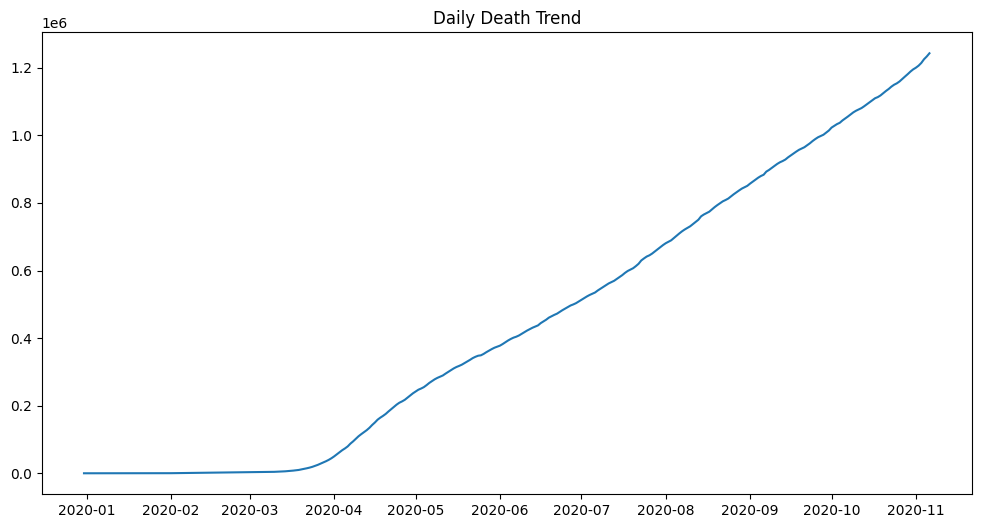

In [48]:
daily = df.groupby('Date')['Death'].sum()
plt.figure(figsize=(12,6))
plt.plot(daily.index, daily.values)
plt.title("Daily Death Trend")
plt.show()

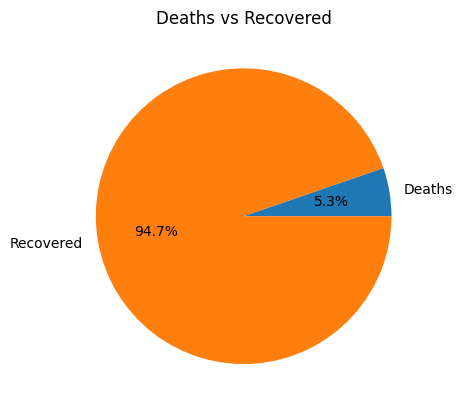

In [49]:
values = [total_deaths, total_recovered]
labels = ['Deaths', 'Recovered']

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Deaths vs Recovered")
plt.show()

In [59]:
import plotly.express as px
fig = px.bar(
    top10,
    x=top10.index,
    y='Death',
    title='Top 10 Countries by Deaths'
)

fig.show()